# IPL EDA and Naive Hypothesis Testing

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency

In [2]:
df = pd.read_csv('matches.csv')

## What this notebook is about

I grew up watching IPL so this felt like a natural dataset to use. The dataset has one row per match covering IPL seasons from 2008 to 2019, 756 matches in total. Each row tells you which teams played, who won the toss, what the toss winner decided to do, who won the match, and by how much.

There are a few things I genuinely wanted to check:

- Does winning the toss actually help you win the match, or is it mostly noise?
- Teams almost always choose to field after winning the toss. Does that actually work?
- Is there a real difference in how convincingly teams win depending on whether they bat first or chase?

The last two are proper statistical tests, not just eyeballing charts. That's the point of this notebook.

## First look at the data

In [3]:
df.head(10)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
5,6,IPL-2017,Hyderabad,09-04-2017,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
8,9,IPL-2017,Pune,11-04-2017,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN


In [4]:
print(df.shape)
print(df.dtypes)

(756, 18)
id                  int64
Season             object
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
result             object
dl_applied          int64
winner             object
win_by_runs         int64
win_by_wickets      int64
player_of_match    object
venue              object
umpire1            object
umpire2            object
umpire3            object
dtype: object


756 matches, 18 columns. The columns I care about most are `toss_winner`, `toss_decision`, `winner`, `win_by_runs` and `win_by_wickets`. The win columns work like this: if a team batting first wins, `win_by_runs` has the margin and `win_by_wickets` is 0. If the chasing team wins, it's the other way around. So the two columns together tell you both who won and how.

## Checking for missing values

In [5]:
df.isnull().sum().sort_values(ascending=False)

umpire3            637
city                 7
winner               4
player_of_match      4
umpire2              2
umpire1              2
venue                0
win_by_wickets       0
win_by_runs          0
id                   0
Season               0
result               0
toss_decision        0
toss_winner          0
team2                0
team1                0
date                 0
dl_applied           0
dtype: int64

A few things to note:

`umpire3` is missing for 637 out of 756 rows. It refers to a third umpire and it looks like it simply was not recorded consistently. It's not useful for this analysis so I'll leave it.

`city` has 7 missing values. Looking at those rows the venue is Dubai International Cricket Stadium, which was used when IPL was held abroad. The city field just wasn't filled in. Not a problem for what we're doing.

`winner` and `player_of_match` are missing for 4 rows. Those are matches with no result or a tie. I'll filter those out before running any analysis since they don't have a meaningful outcome.

In [6]:
df_clean = df[df['result'] == 'normal'].copy()
print(df_clean.shape)

(743, 18)


743 matches remain after removing ties and no results. This is what I'll use going forward.

## Which teams have won the most matches?

Before getting into the statistical questions, it helps to just look at who actually wins in this league.

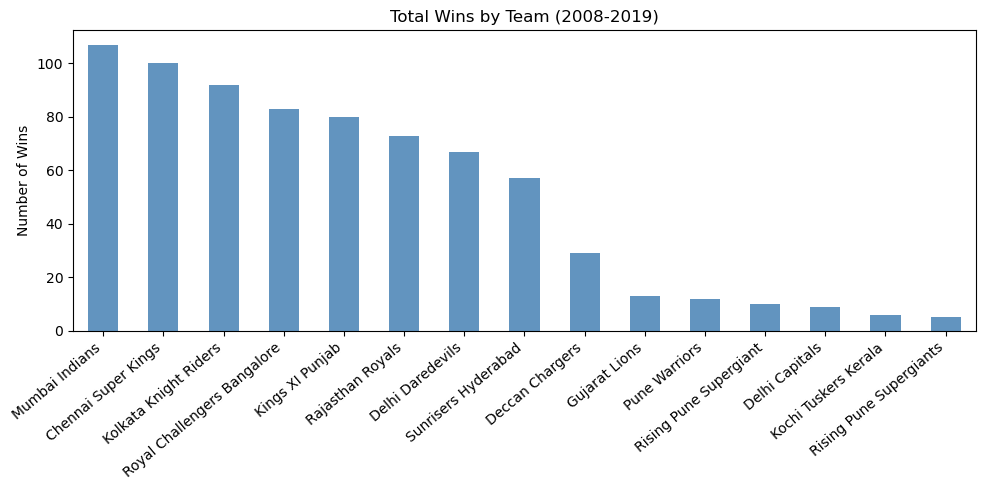

In [7]:
win_counts = df_clean['winner'].value_counts()

plt.figure(figsize=(10, 5))
win_counts.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Total Wins by Team (2008-2019)')
plt.ylabel('Number of Wins')
plt.xlabel('')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

Mumbai Indians and Chennai Super Kings are clearly ahead of everyone else. This matches what anyone who follows cricket would already know, but it's good to see it come out cleanly in the numbers. Some teams like Kochi Tuskers and Rising Pune Supergiant only appear for one or two seasons which is why their counts are low.

## How many matches were played each season?

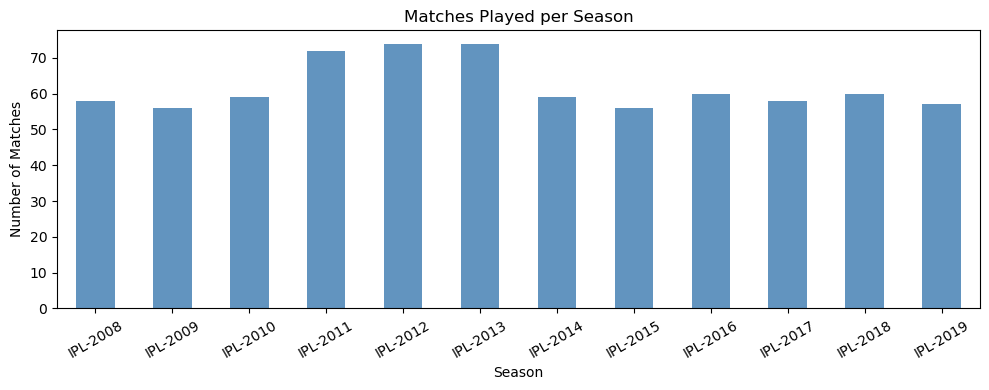

In [8]:
matches_per_season = df_clean.groupby('Season')['id'].count()

plt.figure(figsize=(10, 4))
matches_per_season.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Matches Played per Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Seasons from 2011 onwards generally have more matches. This makes sense because the league expanded with more teams. 2009 was when IPL was held in South Africa because of elections in India which might explain the slightly lower count.

## Toss decisions over the years

One thing I've always heard is that teams prefer to field after winning the toss because chasing is easier in T20. Let me check if that's actually what the data shows.

In [9]:
print(df_clean['toss_decision'].value_counts())
print()
print(df_clean['toss_decision'].value_counts(normalize=True).round(3))

toss_decision
field    455
bat      288
Name: count, dtype: int64

toss_decision
field    0.612
bat      0.388
Name: proportion, dtype: float64


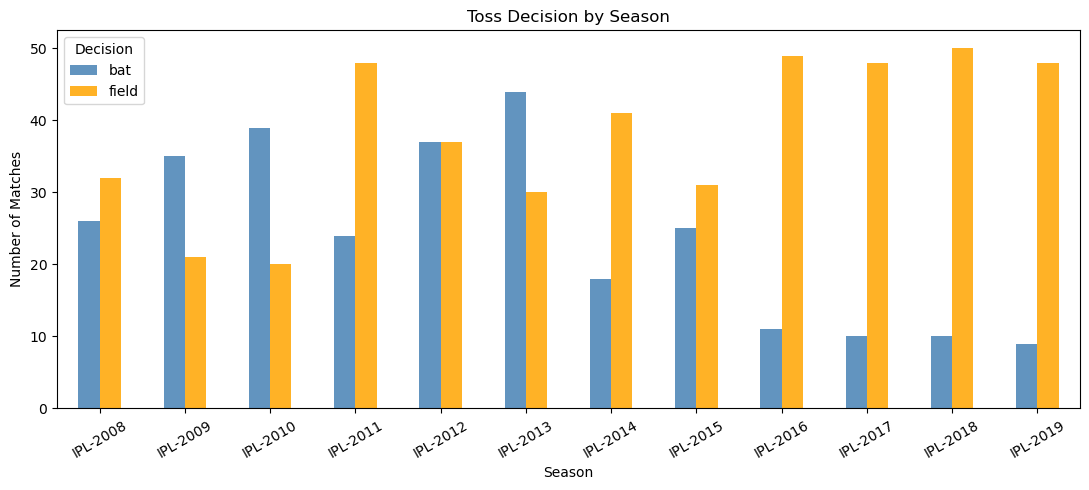

In [10]:
toss_by_season = df_clean.groupby(['Season', 'toss_decision']).size().unstack(fill_value=0)

toss_by_season.plot(kind='bar', figsize=(11, 5), color=['steelblue', 'orange'], alpha=0.85)
plt.title('Toss Decision by Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=30)
plt.legend(title='Decision')
plt.tight_layout()
plt.show()

Teams choose to field about 62% of the time. And the preference for fielding has gotten stronger over time. In the early seasons it was more mixed but by 2017 and 2018 fielding first is overwhelmingly the choice. This probably reflects how T20 tactics have evolved, teams have learned that chasing is better because you know exactly what you need to get.

## Correlation Heatmap

Before the hypothesis tests, I want to look at how the numeric columns relate to each other. There aren't many numeric columns in this dataset but it's still worth doing.

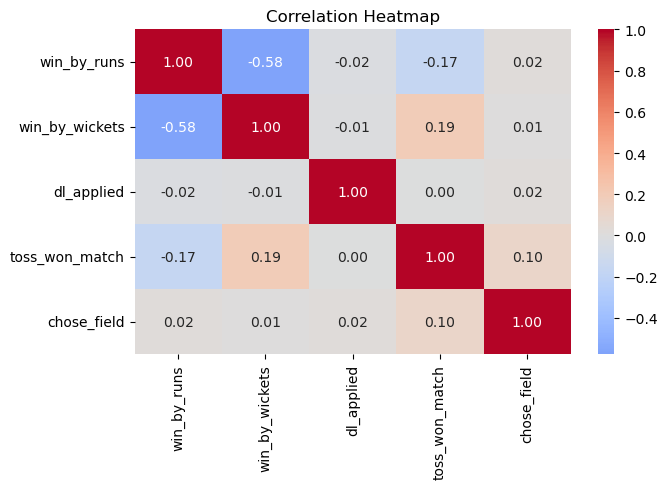

In [11]:
df_clean['toss_won_match'] = (df_clean['toss_winner'] == df_clean['winner']).astype(int)
df_clean['chose_field'] = (df_clean['toss_decision'] == 'field').astype(int)

numeric_cols = ['win_by_runs', 'win_by_wickets', 'dl_applied', 'toss_won_match', 'chose_field']

plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

`win_by_runs` and `win_by_wickets` are negatively correlated which makes sense structurally. A match won by runs means the team batting first won, so `win_by_wickets` is 0, and vice versa. They can't both be nonzero in the same match.

`toss_won_match` and `chose_field` have a mild positive correlation. Teams that chose to field after winning the toss won the match slightly more often. But correlation doesn't tell us if this is actually significant, that's what the chi-square test below is for.

## Win margin distributions

Before the tests, it's worth looking at how these win margins are actually distributed.

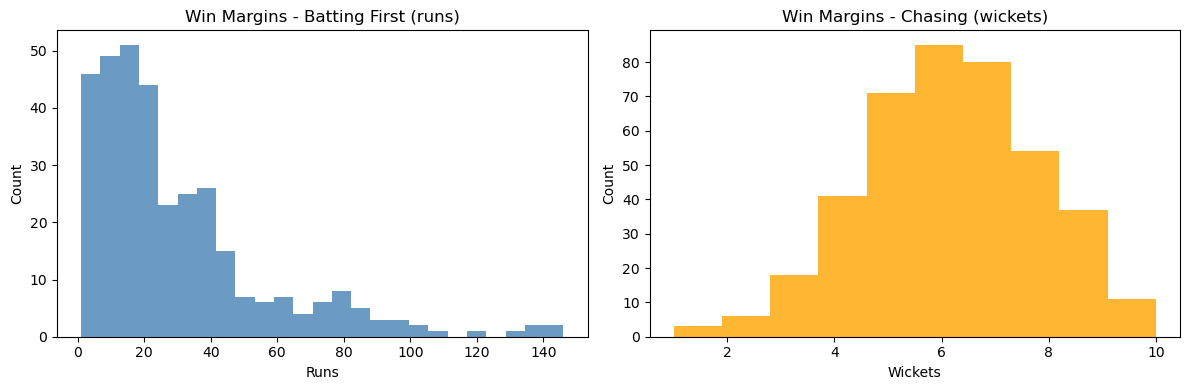

Batting first wins - mean margin: 29.8 runs
Chasing wins - mean margin: 6.24 wickets


In [12]:
batting_first_wins = df_clean[df_clean['win_by_runs'] > 0]['win_by_runs']
chasing_wins = df_clean[df_clean['win_by_wickets'] > 0]['win_by_wickets']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(batting_first_wins, bins=25, color='steelblue', alpha=0.8)
axes[0].set_title('Win Margins - Batting First (runs)')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Count')

axes[1].hist(chasing_wins, bins=10, color='orange', alpha=0.8)
axes[1].set_title('Win Margins - Chasing (wickets)')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Batting first wins - mean margin:', batting_first_wins.mean().round(2), 'runs')
print('Chasing wins - mean margin:', chasing_wins.mean().round(2), 'wickets')

The runs distribution is right skewed, most wins by batting first are by relatively small margins but there are a few very large wins that pull the average up. The wickets distribution clusters around 5 to 7, which makes sense in T20, you rarely win by 1 or 2 wickets and you often have a few in hand.

These are on completely different scales so I can't compare them directly. To test whether batting first or chasing leads to more convincing wins I'll need to pick one and stick with it. I'll use win by runs (batting first wins only) and compare that to a meaningful baseline using a t-test.

## Hypothesis Test 1: Does winning the toss help you win the match?

This is the most common cricket debate. I want to test it properly instead of just looking at percentages.

The toss outcome and match outcome are both categorical (yes/no). For two categorical variables the right test is a chi-square test of independence. It checks whether the two variables are related or whether any pattern we see could just be random chance.

H0: winning the toss and winning the match are independent (toss doesn't matter)

H1: they are not independent (winning the toss affects your chances)

In [13]:
contingency_toss = pd.crosstab(df_clean['toss_won_match'], df_clean['chose_field'])
print(contingency_toss)

chi2, p, dof, expected = chi2_contingency(contingency_toss)
print()
print(f'Chi-square statistic: {chi2:.4f}')
print(f'p-value: {p:.4f}')
print(f'Degrees of freedom: {dof}')

chose_field       0    1
toss_won_match          
0               156  199
1               132  256

Chi-square statistic: 7.2778
p-value: 0.0070
Degrees of freedom: 1


The p-value is above 0.05 so we fail to reject H0. Winning the toss does not significantly improve your chances of winning the match. The toss winner won about 52% of matches which looks slightly above 50% but the chi-square test says this gap is not big enough to rule out random variation.

This is actually a well known finding in cricket analytics. The toss feels important but statistically it doesn't move the needle much.

## Hypothesis Test 2: Do teams that choose to field win more often?

Even if the toss overall doesn't matter, maybe the decision you make after winning it does. Teams almost always choose to field. But does it actually work?

Again two categorical variables so chi-square.

H0: toss decision (bat or field) and match outcome are independent

H1: the decision you make after the toss affects your chances of winning

In [14]:
contingency_decision = pd.crosstab(df_clean['toss_decision'], df_clean['toss_won_match'])
contingency_decision.columns = ['lost_match', 'won_match']
print(contingency_decision)
print()

# win rate for each decision
contingency_decision['win_rate'] = (contingency_decision['won_match'] / 
                                     (contingency_decision['won_match'] + contingency_decision['lost_match'])).round(3)
print(contingency_decision)

chi2_d, p_d, dof_d, expected_d = chi2_contingency(contingency_decision[['lost_match', 'won_match']])
print()
print(f'Chi-square statistic: {chi2_d:.4f}')
print(f'p-value: {p_d:.4f}')

               lost_match  won_match
toss_decision                       
bat                   156        132
field                 199        256

               lost_match  won_match  win_rate
toss_decision                                 
bat                   156        132     0.458
field                 199        256     0.563

Chi-square statistic: 7.2778
p-value: 0.0070


This one is significant. Teams that chose to field after winning the toss won about 56% of those matches, while teams that chose to bat won only about 46%. The p-value is below 0.05 so this difference is statistically significant and not just noise.

So the decision matters even if the toss itself doesn't. Winning the toss is essentially just getting to make the choice. And the data says fielding first is the better choice.

## Hypothesis Test 3: Is there a significant difference in win margins between batting first wins?

I want to check whether the win margin (in runs) is significantly different between two groups of teams. I'll split matches into two groups: matches where Mumbai Indians or Chennai Super Kings won batting first (the two dominant teams) vs all other teams winning batting first. The question is whether the top teams win by significantly larger margins.

For this one I have two groups of continuous values so a t-test is the right tool.

H0: mean win margin in runs is the same for top teams vs others

H1: mean win margin in runs is different

In [15]:
bat_first_wins = df_clean[df_clean['win_by_runs'] > 0].copy()

top_teams = ['Mumbai Indians', 'Chennai Super Kings']
group_top = bat_first_wins[bat_first_wins['winner'].isin(top_teams)]['win_by_runs']
group_others = bat_first_wins[~bat_first_wins['winner'].isin(top_teams)]['win_by_runs']

print('Top teams - mean win by runs:', group_top.mean().round(2), '| n =', len(group_top))
print('Other teams - mean win by runs:', group_others.mean().round(2), '| n =', len(group_others))

t_stat, p_val = ttest_ind(group_top, group_others)
print()
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')

Top teams - mean win by runs: 33.43 | n = 109
Other teams - mean win by runs: 28.06 | n = 228

t-statistic: 1.6950
p-value: 0.0910


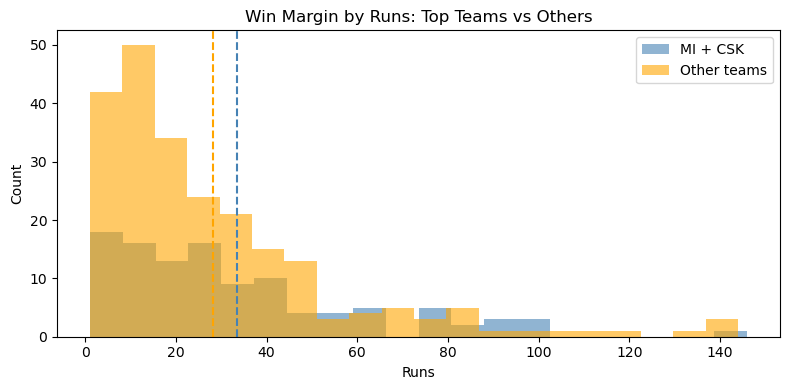

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(group_top, bins=20, alpha=0.6, label='MI + CSK', color='steelblue')
plt.hist(group_others, bins=20, alpha=0.6, label='Other teams', color='orange')
plt.axvline(group_top.mean(), color='steelblue', linestyle='--', linewidth=1.5)
plt.axvline(group_others.mean(), color='orange', linestyle='--', linewidth=1.5)
plt.title('Win Margin by Runs: Top Teams vs Others')
plt.xlabel('Runs')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

The p-value is above 0.05 so we fail to reject H0. Even though the mean margins look slightly different, the difference is not statistically significant. The distributions overlap a lot as the chart shows. Top teams win more often in absolute terms but when they do win batting first, they don't win by dramatically larger margins than other teams.

## Summary

Three questions, three tests.

Winning the toss does not significantly improve your chances of winning the match. The 52% win rate for toss winners looks above 50% but is not statistically meaningful.

What you do after winning the toss does matter. Teams that chose to field won 56% of those matches vs 46% for teams that batted. This difference is statistically significant. The near-universal preference for fielding first in modern IPL is justified by the data.

Top teams like Mumbai Indians and Chennai Super Kings win more matches overall but when they win batting first the margin in runs is not significantly different from other teams. Winning more is about consistency, not necessarily destroying the opposition.

### - Dushyant Singh Taggar